Phys474 - Spring 2023

Lab 3 - The Time Dependent Schrodinger Equation 

<font color='red'>Author: Djamil Lakhdar-Hamina

In this lab you will gain practice in calculating the TDSE for various potentials. In particular we will examine the scattering of a guassian wave packet from 
- Step Potential
- Barrier Potential

The Schrodinger equation is given by

$i\hbar\frac{\partial\Psi(x)}{\partial x} = \hat{H}\Psi(x)$ 

or,

$i\hbar\frac{\partial\Psi(x)}{\partial x} = -\frac{\hbar^2}{2m}\nabla^2\Psi(x)+V(x)\Psi(x)$ 

We implement this in 1D using the Hamiltonian as we did for the TISE

the QM Hamiltonian is given by

$\hat{H}=T+V=-\frac{\hbar^2}{2m}\nabla^2+V$

The Laplacian $\nabla^2$ in 1D is given by an $nxn$ matrix

$\nabla^2= \frac{\partial^2}{\partial x^2}=
\frac{1}{a^2}\begin{pmatrix}
-2& 1 & 0& 0&0&\ldots \\
1 &-2 & 1 &0 &0 &\ldots\\
0 & 1 & -2& 1 & 0 & \ldots \\
0 & 0 &1&-2&1&\ldots \\
\vdots&\vdots&\vdots&\vdots&\vdots&\ddots
\end{pmatrix}$

where we put the problem on a grid of $n$ points in $x$ with spacing $a$.


Then for the Hamiltonian we have

$\hat{H}=T+V=-\frac{\hbar^2}{2m}\nabla^2+V = \frac{-\hbar^2}{2ma^2}\begin{pmatrix}
-2& 1 & 0& 0&0&\ldots \\
1 &-2 & 1 &0 &0 &\ldots\\
0 & 1 & -2& 1 & 0 & \ldots \\
0 & 0 &1&-2&1&\ldots \\
\vdots&\vdots&\vdots&\vdots&\vdots&\ddots
\end{pmatrix}  + 
\begin{pmatrix}
V(x_1)& 0 & 0& 0&0&\ldots \\
0 &V(x_2) & 0 &0 &0 &\ldots\\
0 & 0 & V(x_3)& 0 & 0 & \ldots \\
0 & 0 &0&V(x_4)&0&\ldots \\
\vdots&\vdots&\vdots&\vdots&\vdots&\ddots
\end{pmatrix} 
$

<br><br>
    
We will be examining the "motion" of an initial wavefunction $\psi(x,0)$ given as a gaussian wave packet, which are very often used
as a way to represent a "particle" of mean wavenumber (i.e. momentum) $k_0$. 

A Gaussian wave packet properly normalized such that 

$\int_{-\infty}^{\infty} \left|\psi(x,0)\right|^2  dx =1 $

is then given by

$\psi(x,0) = \frac{1}{\sqrt{\sigma_x\sqrt{2\pi}}}e^{-\frac{(x-x_0)^2}{4\sigma_x^2}}e^{ik_0x}$

where $x_0$ is the central position and $\sigma_x$ is the "spatial width" of $\left|\psi(x,0)\right|^2$ and $k_0$ is the mean wave number (i.e moving to the right with mean $k_0$).


___________________________________________________________________________________
Use the following unless instructed otherwise

- Use atomic units $\hbar =1$, use $m=m_e=1$
- use an array for $x$ with spacing $.01$ and $0\le x \le 50.$
- use an array for times with spacing $0.005$ and $0\le t \le 4$
- for the wave packet use $x_0=12.5$ and $\sigma_x=1$ unless directed otherwise
- Make your plots and animations like the example from lecture on Lab 2 with $V(x)$, $\left<E\right>$ with band of $\pm 2\sigma_E$, $|\Psi(x)|^2$

+++++++++++++++++++++++++++++++++++++++++++<br>
For the Step Potential use

$V(x)=0$ for $0\le x\le 25$ <br>
$V(x)=40$ for $25\lt x\le 50 $<br>
+++++++++++++++++++++++++++++++++++++++++++

+++++++++++++++++++++++++++++++++++++++++++<br>
For the Barrier Potential use 


$V(x)=V_0$ for $25\lt x\le 25+W$ <br>
$V(x)=0$ otherwise <br>

where $W$ is the width in a.u. and $V_0$ is the barrier potential, which can also be negative. Both will be 
specified below for various cases<br>
+++++++++++++++++++++++++++++++++++++++++++



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import solve_ivp
from scipy import sparse
%matplotlib notebook 

hbar=1
m=1
x0=12.5
xmin=0
xmax=50
σₓ=1 
dx=.01
t0=0.0
tf=4.0
dt=.005
N=int((50.0-0.0)/dx)
NT=int((tf-t0)/dt)
step_=N//2
x=np.linspace(0.0,50.0,N)
t=np.linspace(t0,tf,NT)

# laplacian= (np.diag(-2.0*np.ones(N))+np.diag(np.ones(N-1),1)+ \
#     np.diag(np.ones(N-1),-1))/dx**2

laplacian=sparse.diags([1, -2, 1], [-1, 0, 1], shape=(N, N)) / dx**2

def ψₜ(t,ψ,V):
    return -1j*(-hbar/(2*m)*laplacian.dot(ψ)+V/hbar*ψ)

def packet(σ,x,x0,k):
    A=1/(σ*(2*np.pi)**(1/2))**(1/2)
    return A*np.exp(-(x-x0)**2/(4*σ**2))*np.exp(1j*k*x)

def energy_parameters(k0,sigma):
    sig_x=sigma
    energy=hbar**2*(k0**2/(2*m))
    kx_sigma=1/(2*sig_x)
    energy_sigma=hbar**2*k0*kx_sigma/m
    e_ul=energy+2*energy_sigma
    e_ll=energy-2*energy_sigma
    return energy,e_ul,e_ll,energy_sigma
   
def step(N,ϕ0):
    ϕ_step=np.zeros((N,N))
    for i in range(N//2-1,N):
        ϕ_step[i,i]=ϕ0
    return ϕ_step

def barrier(N,ϕ0,x,dx,width):
    ϕ_barrier=np.zeros((N,N))
    dx=(x[N//2]+width-x[N//2])//dx
    for i in range(N//2,int(N//2+dx)):
        ϕ_barrier[i,i]=ϕ0
    return ϕ_barrier

________________________________________________________________________________
Part 1 (5 points)


- make a single plot with 2 subplots top: the $Re(\Psi(x))$, $Im(\Psi(x))$ and $|\Psi(x)|$ for $k_0=5$ and $\sigma_x=1.0$, bottom:  the Fourier Transform from $x$ space to $k$ space $|f(k)|=|FFT(\Psi(x))|$
- make a single plot with 2 subplots top: the $Re(\Psi(x))$, $Im(\Psi(x))$ and $|\Psi(x)|$ for $k_0=5$ and $\sigma_x=.5$, bottom:  the Fourier Transform from $x$ space to $k$ space $|f(k)|=|FFT(\Psi(x))|$
- make a single plot with 2 subplots top: the $Re(\Psi(x))$, $Im(\Psi(x))$ and $|\Psi(x)|$ for $k_0=9$ and $\sigma_x=1.0$, bottom:  the Fourier Transform from $x$ space to $k$ space $|f(k)|=|FFT(\Psi(x))|$

Note: when you do the fft on $\Psi(x)$ you are transforming to $1/x$ space to represent the result as $f(k)$ vs $k$ you have to multiply the $1/x$=axis number by $2\pi$ to get it in $k$ space
___________________________________________________________________________________

<IPython.core.display.Javascript object>


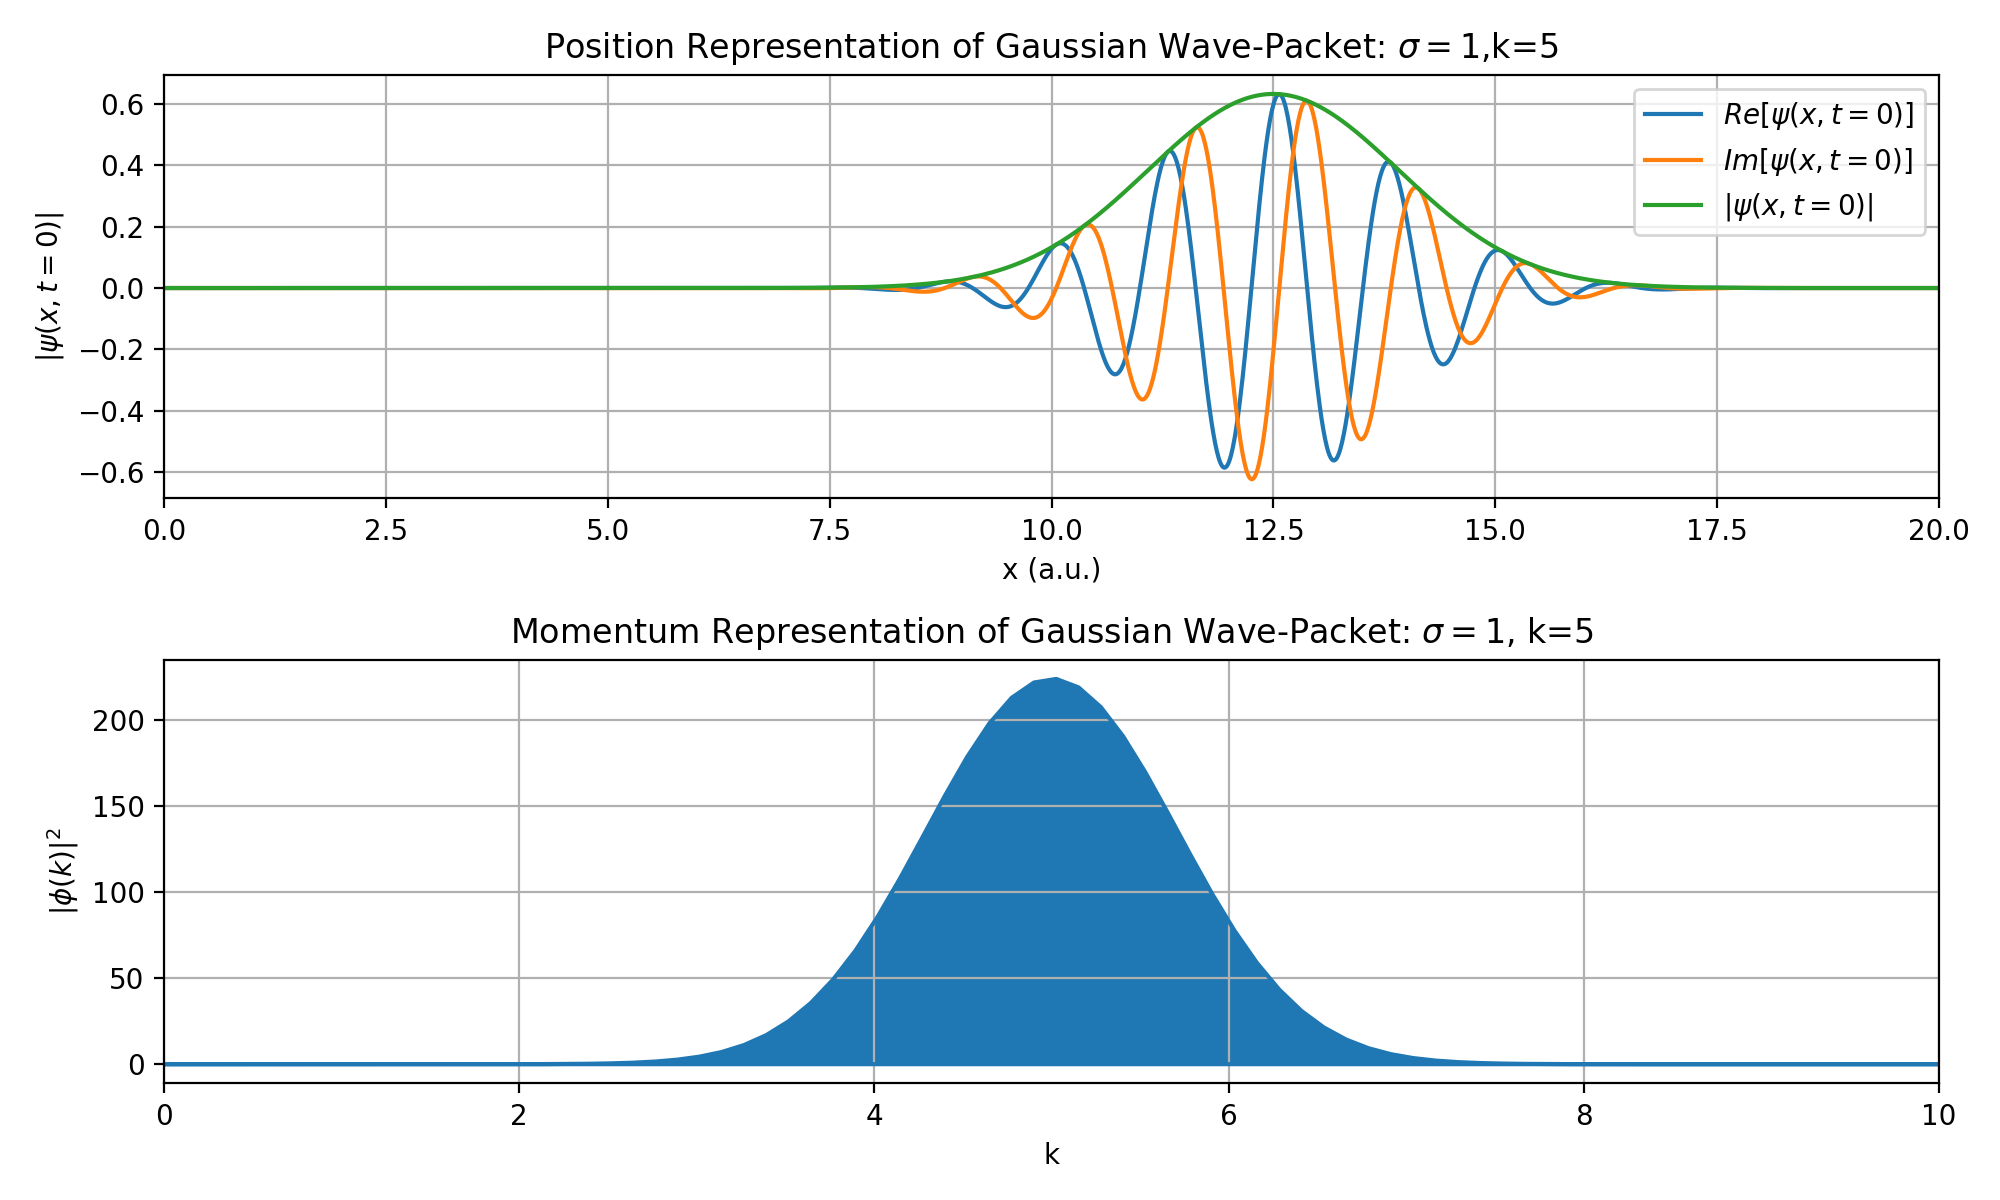

<IPython.core.display.Javascript object>


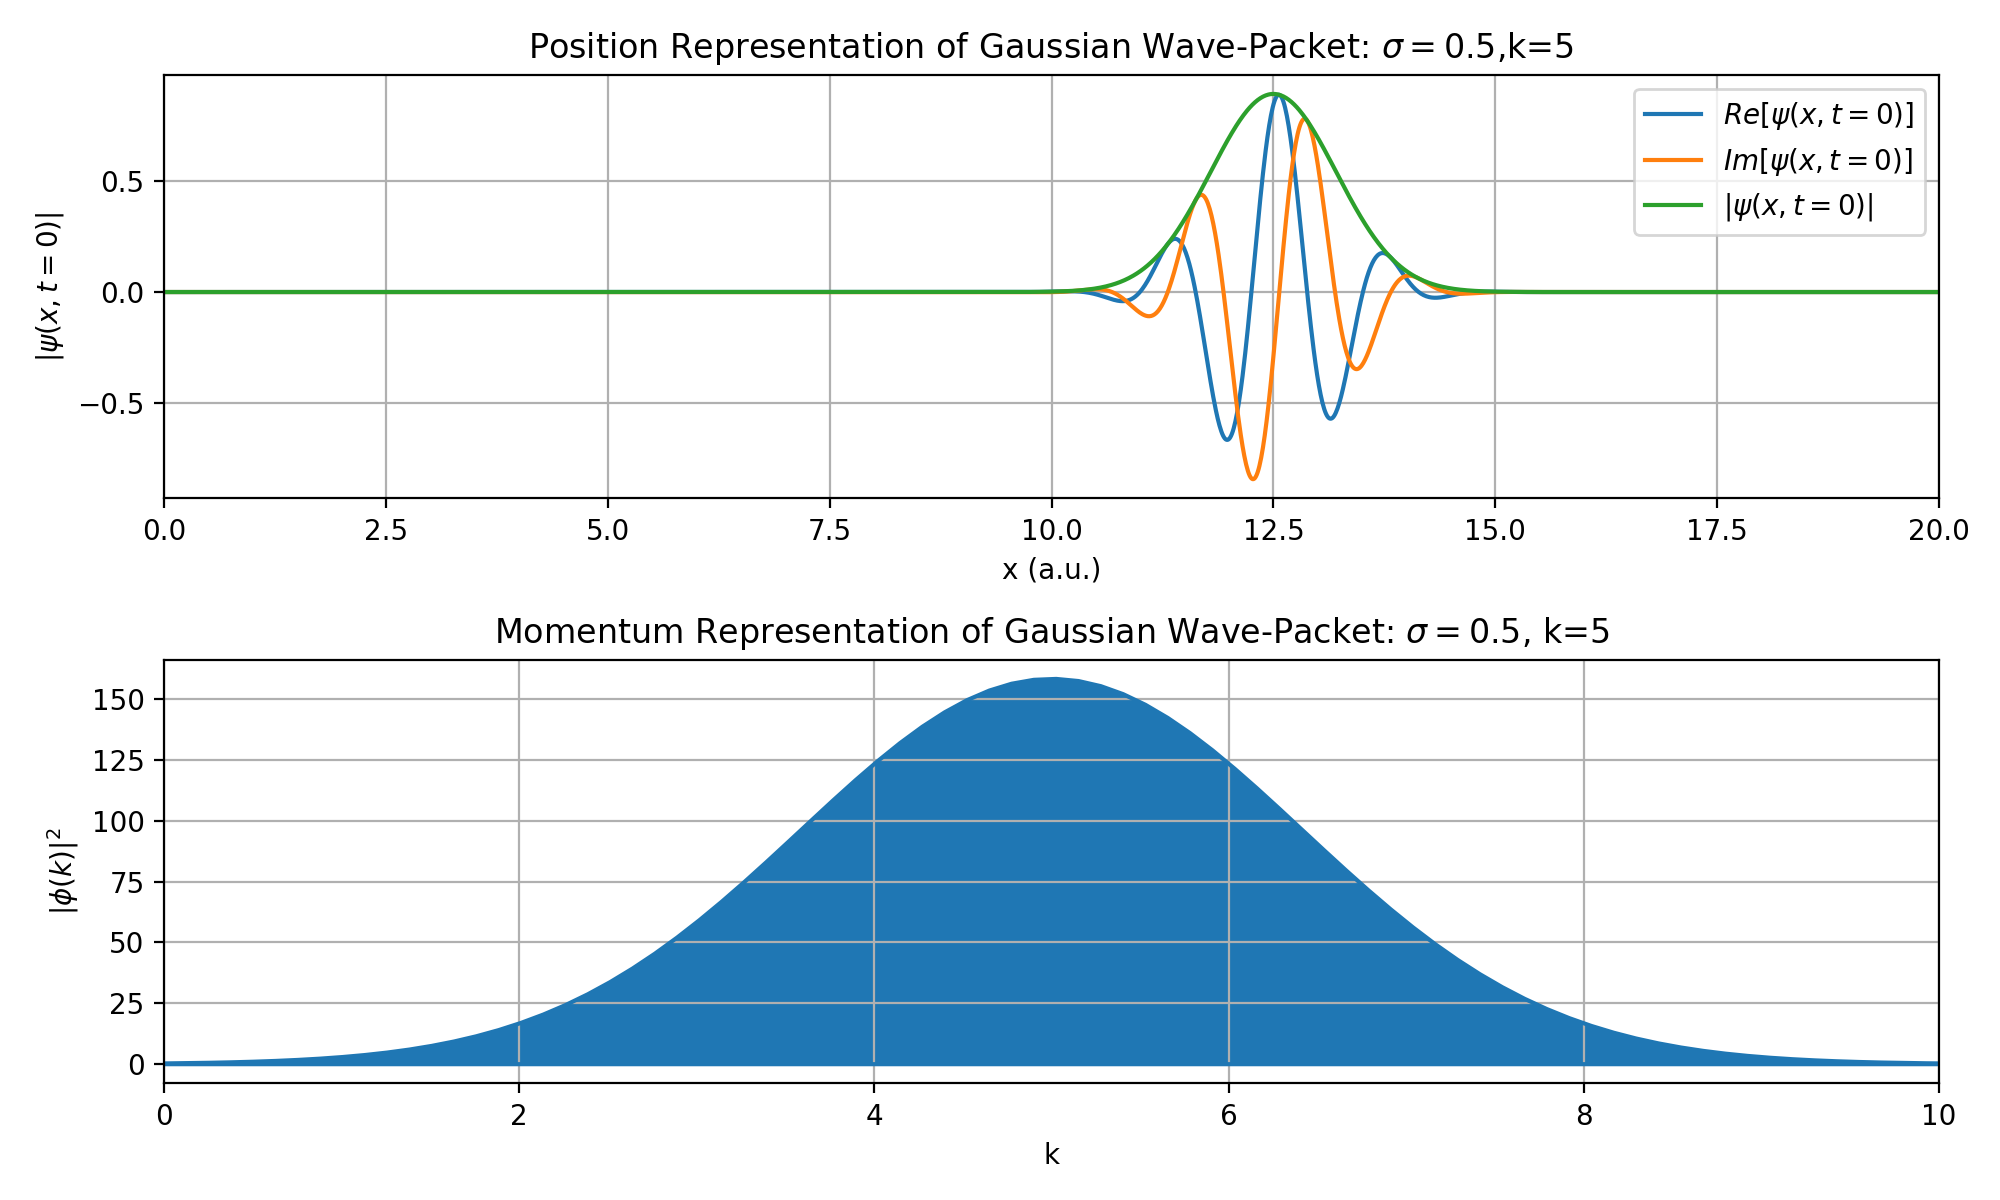

<IPython.core.display.Javascript object>


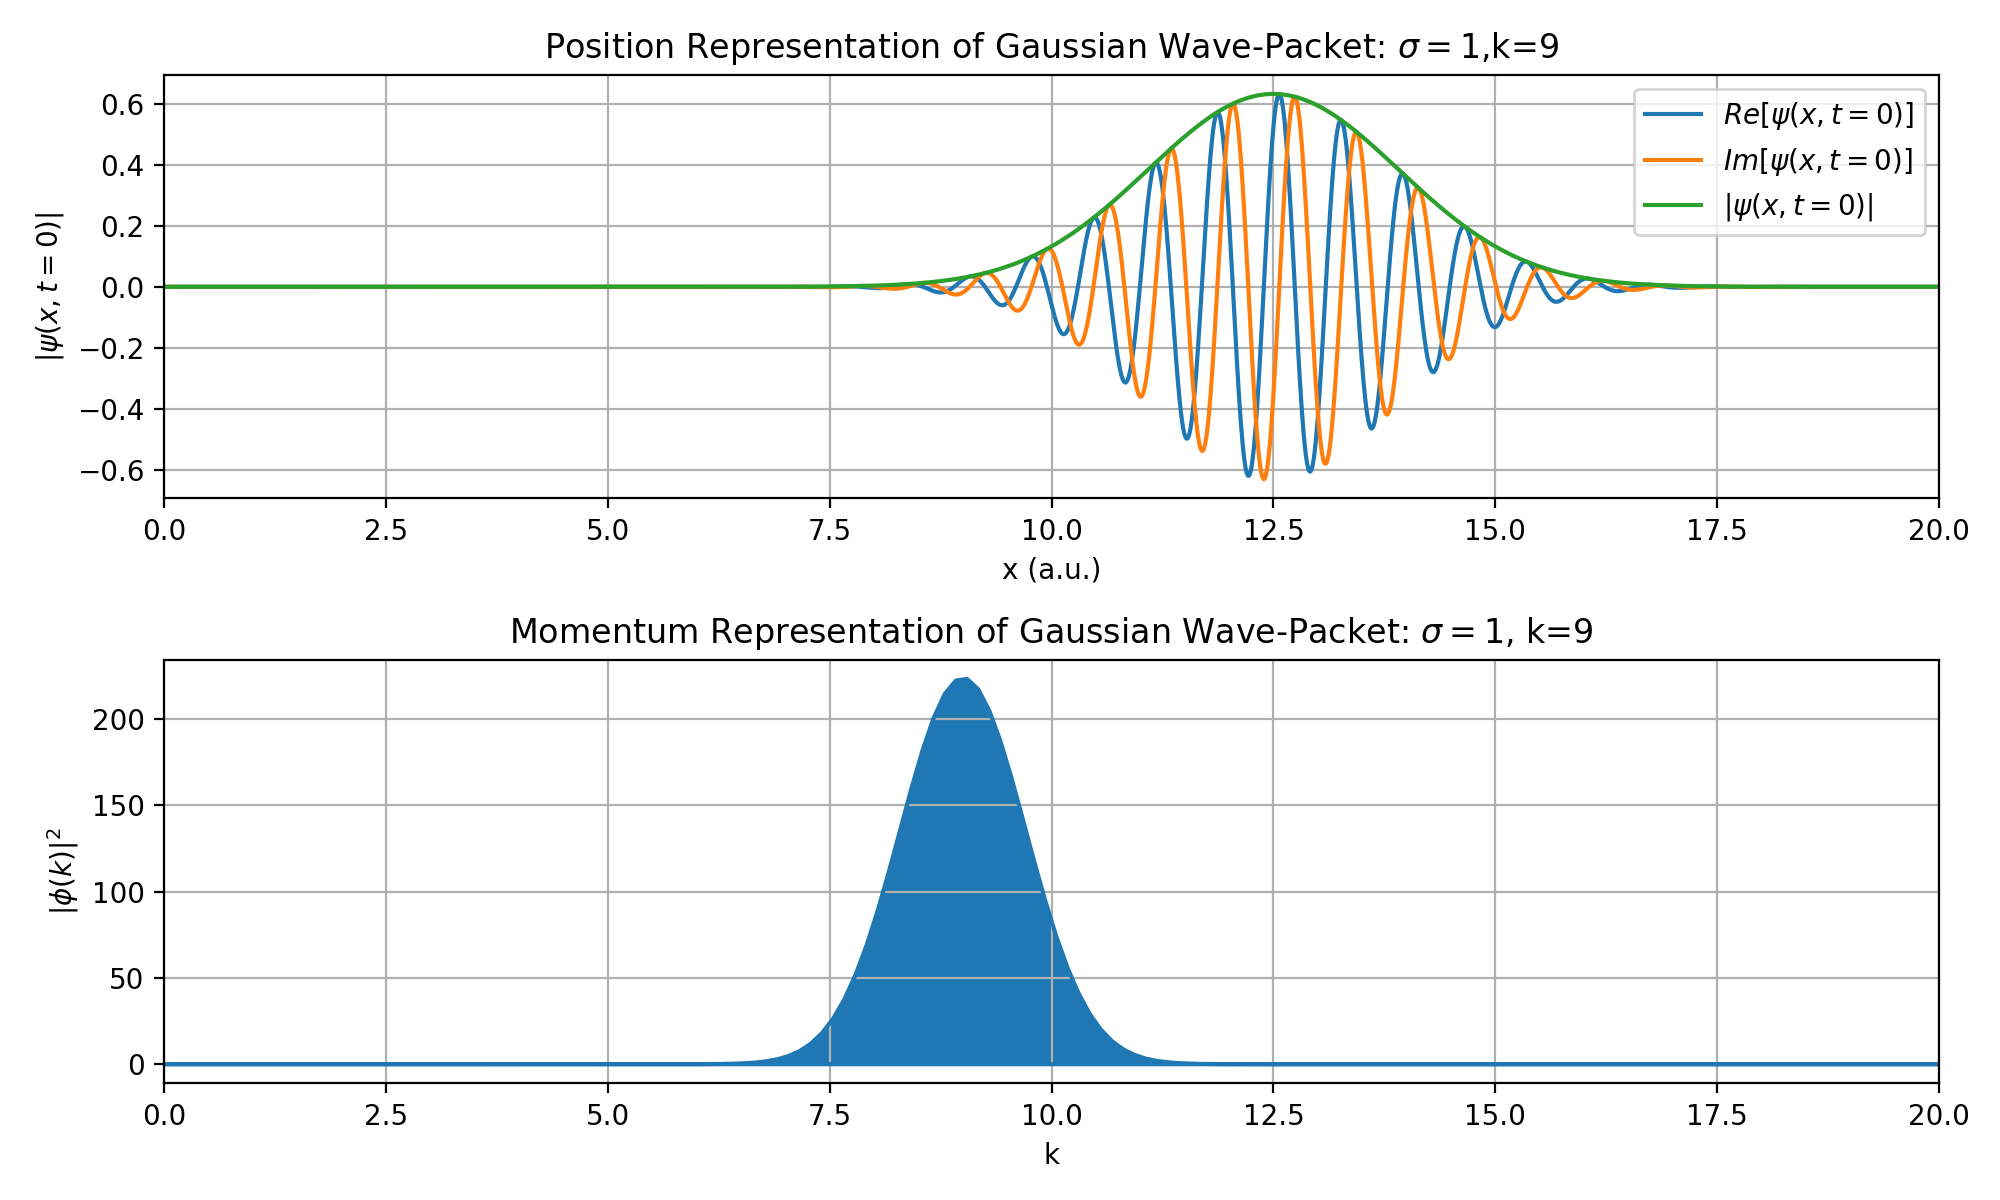

In [2]:
experiment=[(5,1),(5,.5),(9,1)]

for (k,sigma) in experiment:
    ψ=packet(sigma,x,x0,k)
    fig, ax1 = plt.subplots(2,1,figsize=(10,6))
    ax1[0].plot(x,ψ.real,label=r"$Re[\psi(x,t=0)]$")
    ax1[0].plot(x,ψ.imag,label=r"$Im[\psi(x,t=0)]$")
    ax1[0].plot(x,abs(ψ),label=r"$|\psi(x,t=0)|$")
    ax1[0].grid('--')
    ax1[0].set_title(r"Position Representation of Gaussian Wave-Packet: $\sigma=$"+f"{sigma},k={k}")
    ax1[0].set_xlabel("x (a.u.)")
    ax1[0].set_ylabel(r"$|\psi(x,t=0)|$")
    ax1[0].set_xlim((0,20))
    ax1[0].legend()

    freq=np.fft.fftfreq(x.size,dx)
    spectrum=np.fft.fft(ψ)
    ax1[1].plot(2*np.pi*freq,np.abs(spectrum))
    ax1[1].fill_between(2*np.pi*freq,np.abs(spectrum))
    ax1[1].grid('--')
    ax1[1].set_title(r"Momentum Representation of Gaussian Wave-Packet: $\sigma=$" + f"{sigma}, k={k}")
    ax1[1].set_xlabel("k")
    ax1[1].set_ylabel(r"$|\phi(k)|^2$")
    if k==9:
        ax1[1].set_xlim((0,20))
    else:
        ax1[1].set_xlim((0,10))
    plt.tight_layout()
    
plt.show()

## _____________________________________________________________________________________
Part 2: (7 points)

In this part we will make a plot with for each of the various initial conditions

- Each case should be a figure with 3 subplots (1 for each $k_0$)
- on each subplot plot the potential, the mean energy $E_{mean}$ with a band showing the $\pm 2\sigma_E$
- The initial wavefunction squared $|\psi(x,0)|^2$ on the line for $E_{mean}$

a) Step Potential, $V_0=40$
- $k_0=7$
- $k_0=9$
- $k_0=10$

b) Barrier Potential $W=.25$, $V_0=40$
- $k_0=7$
- $k_0=9$
- $k_0=10$

c) Barrier Potential $W=1$, $V_0=40$
- $k_0=7$
- $k_0=9$
- $k_0=10$

d) Barrier Potential $W=.25$, $V_0=-20$
- $k_0=7$
- $k_0=9$
- $k_0=10$


____________________________________________________________________________________

<IPython.core.display.Javascript object>


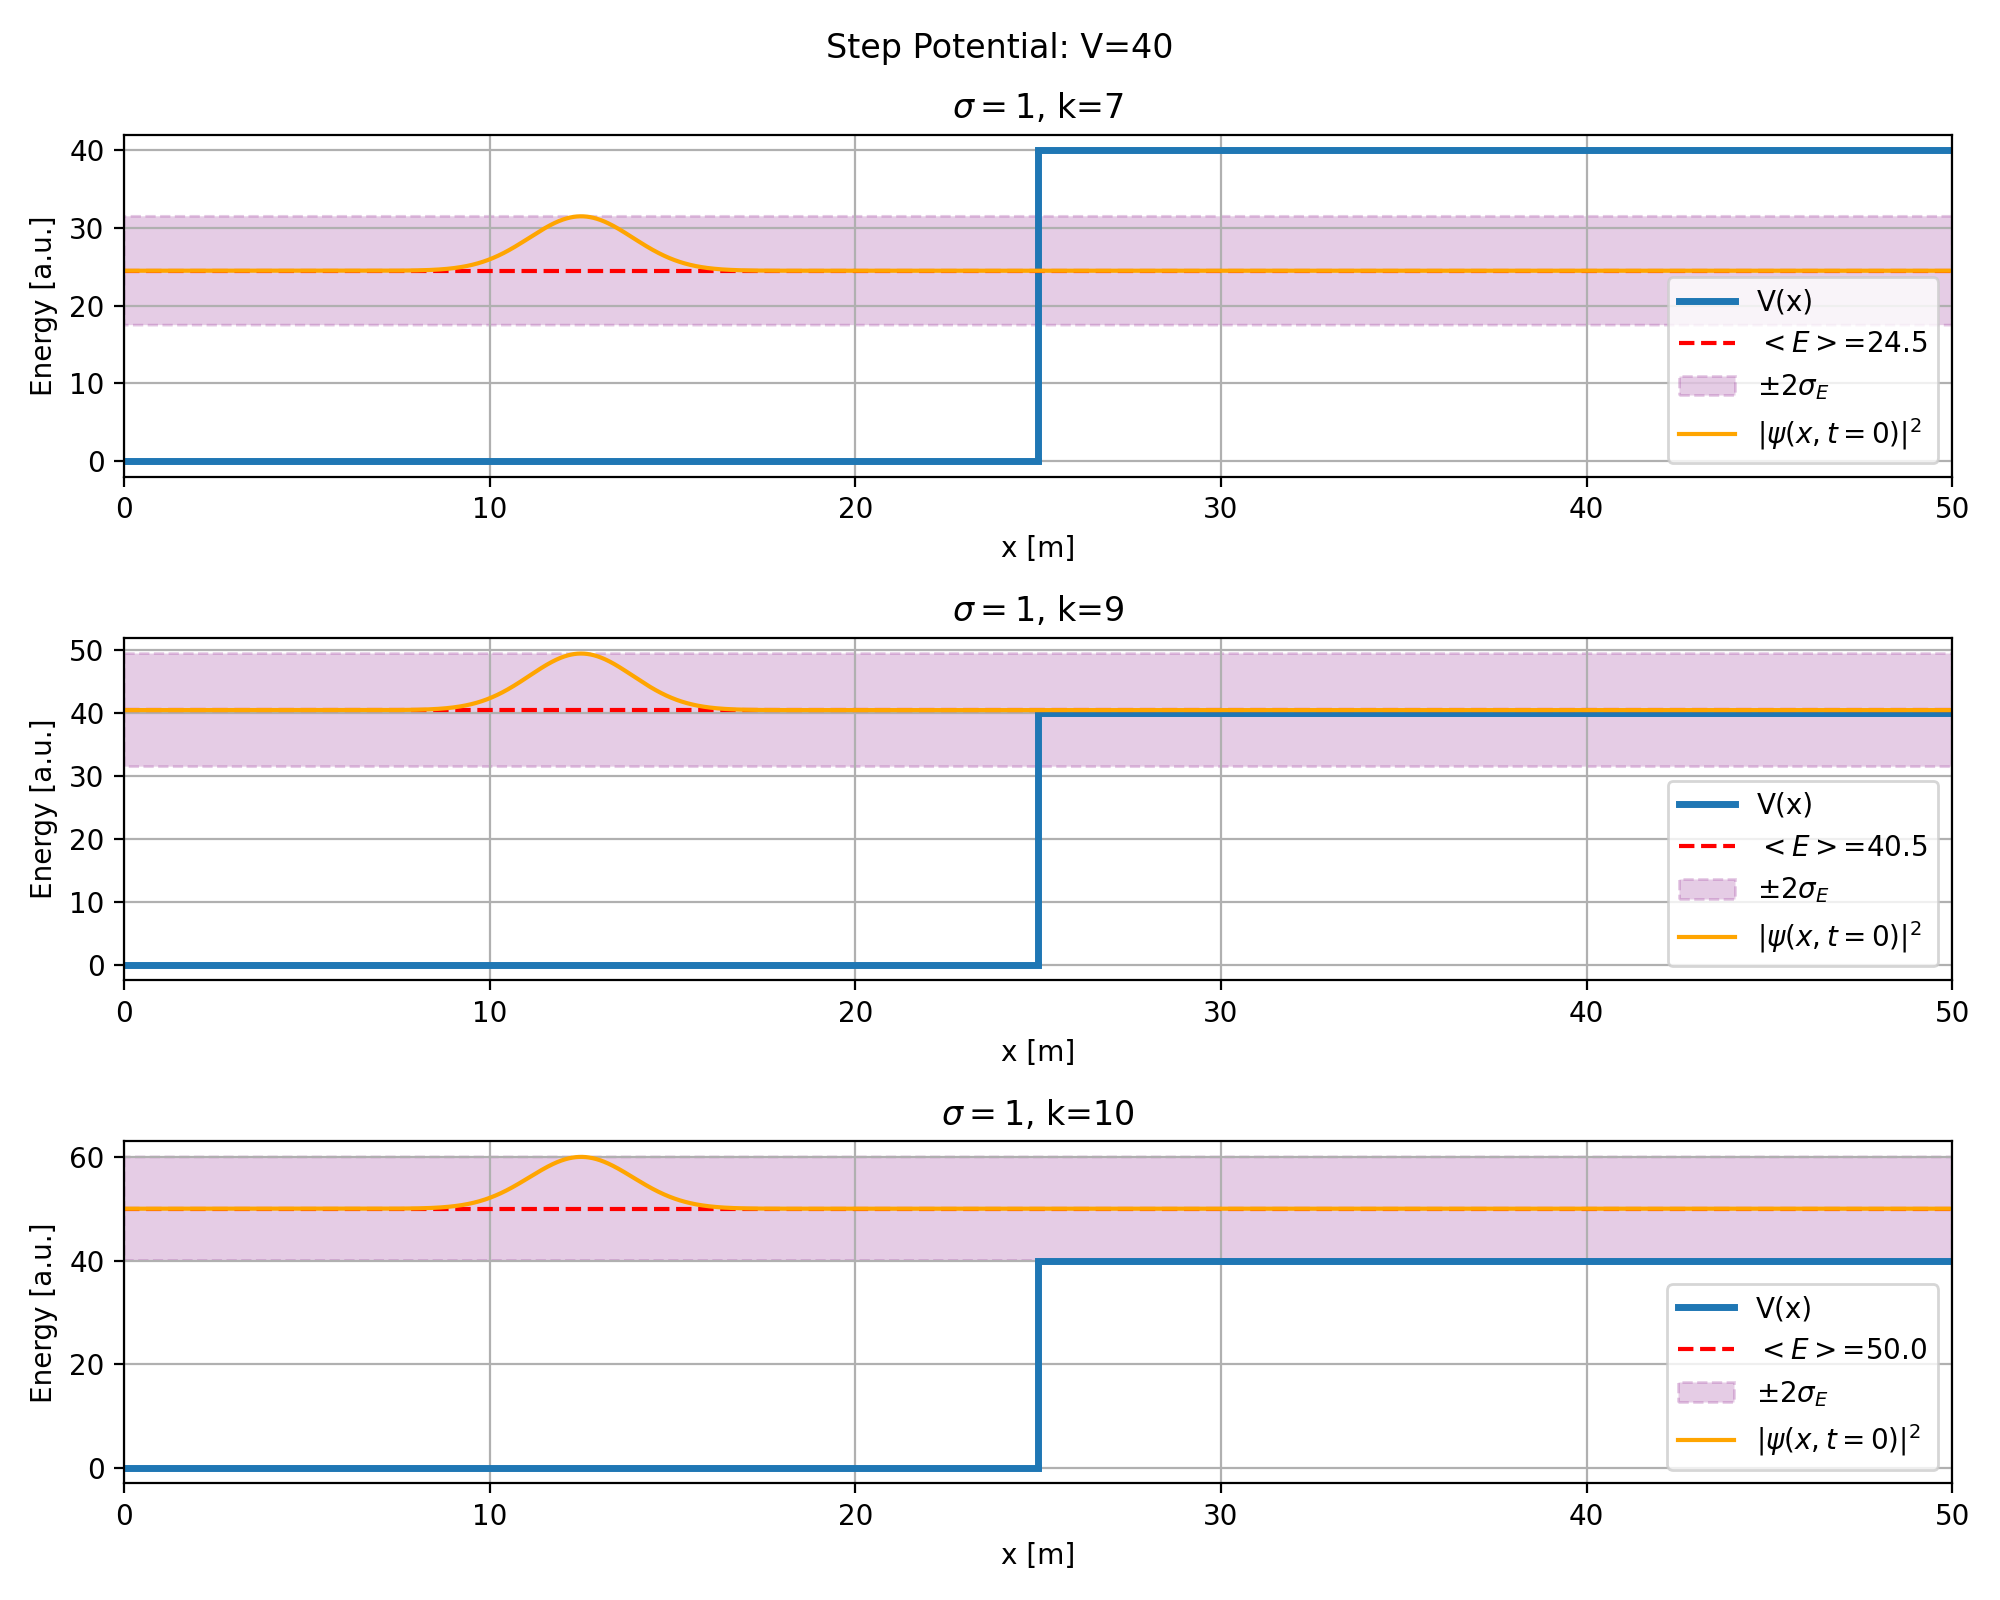

<IPython.core.display.Javascript object>


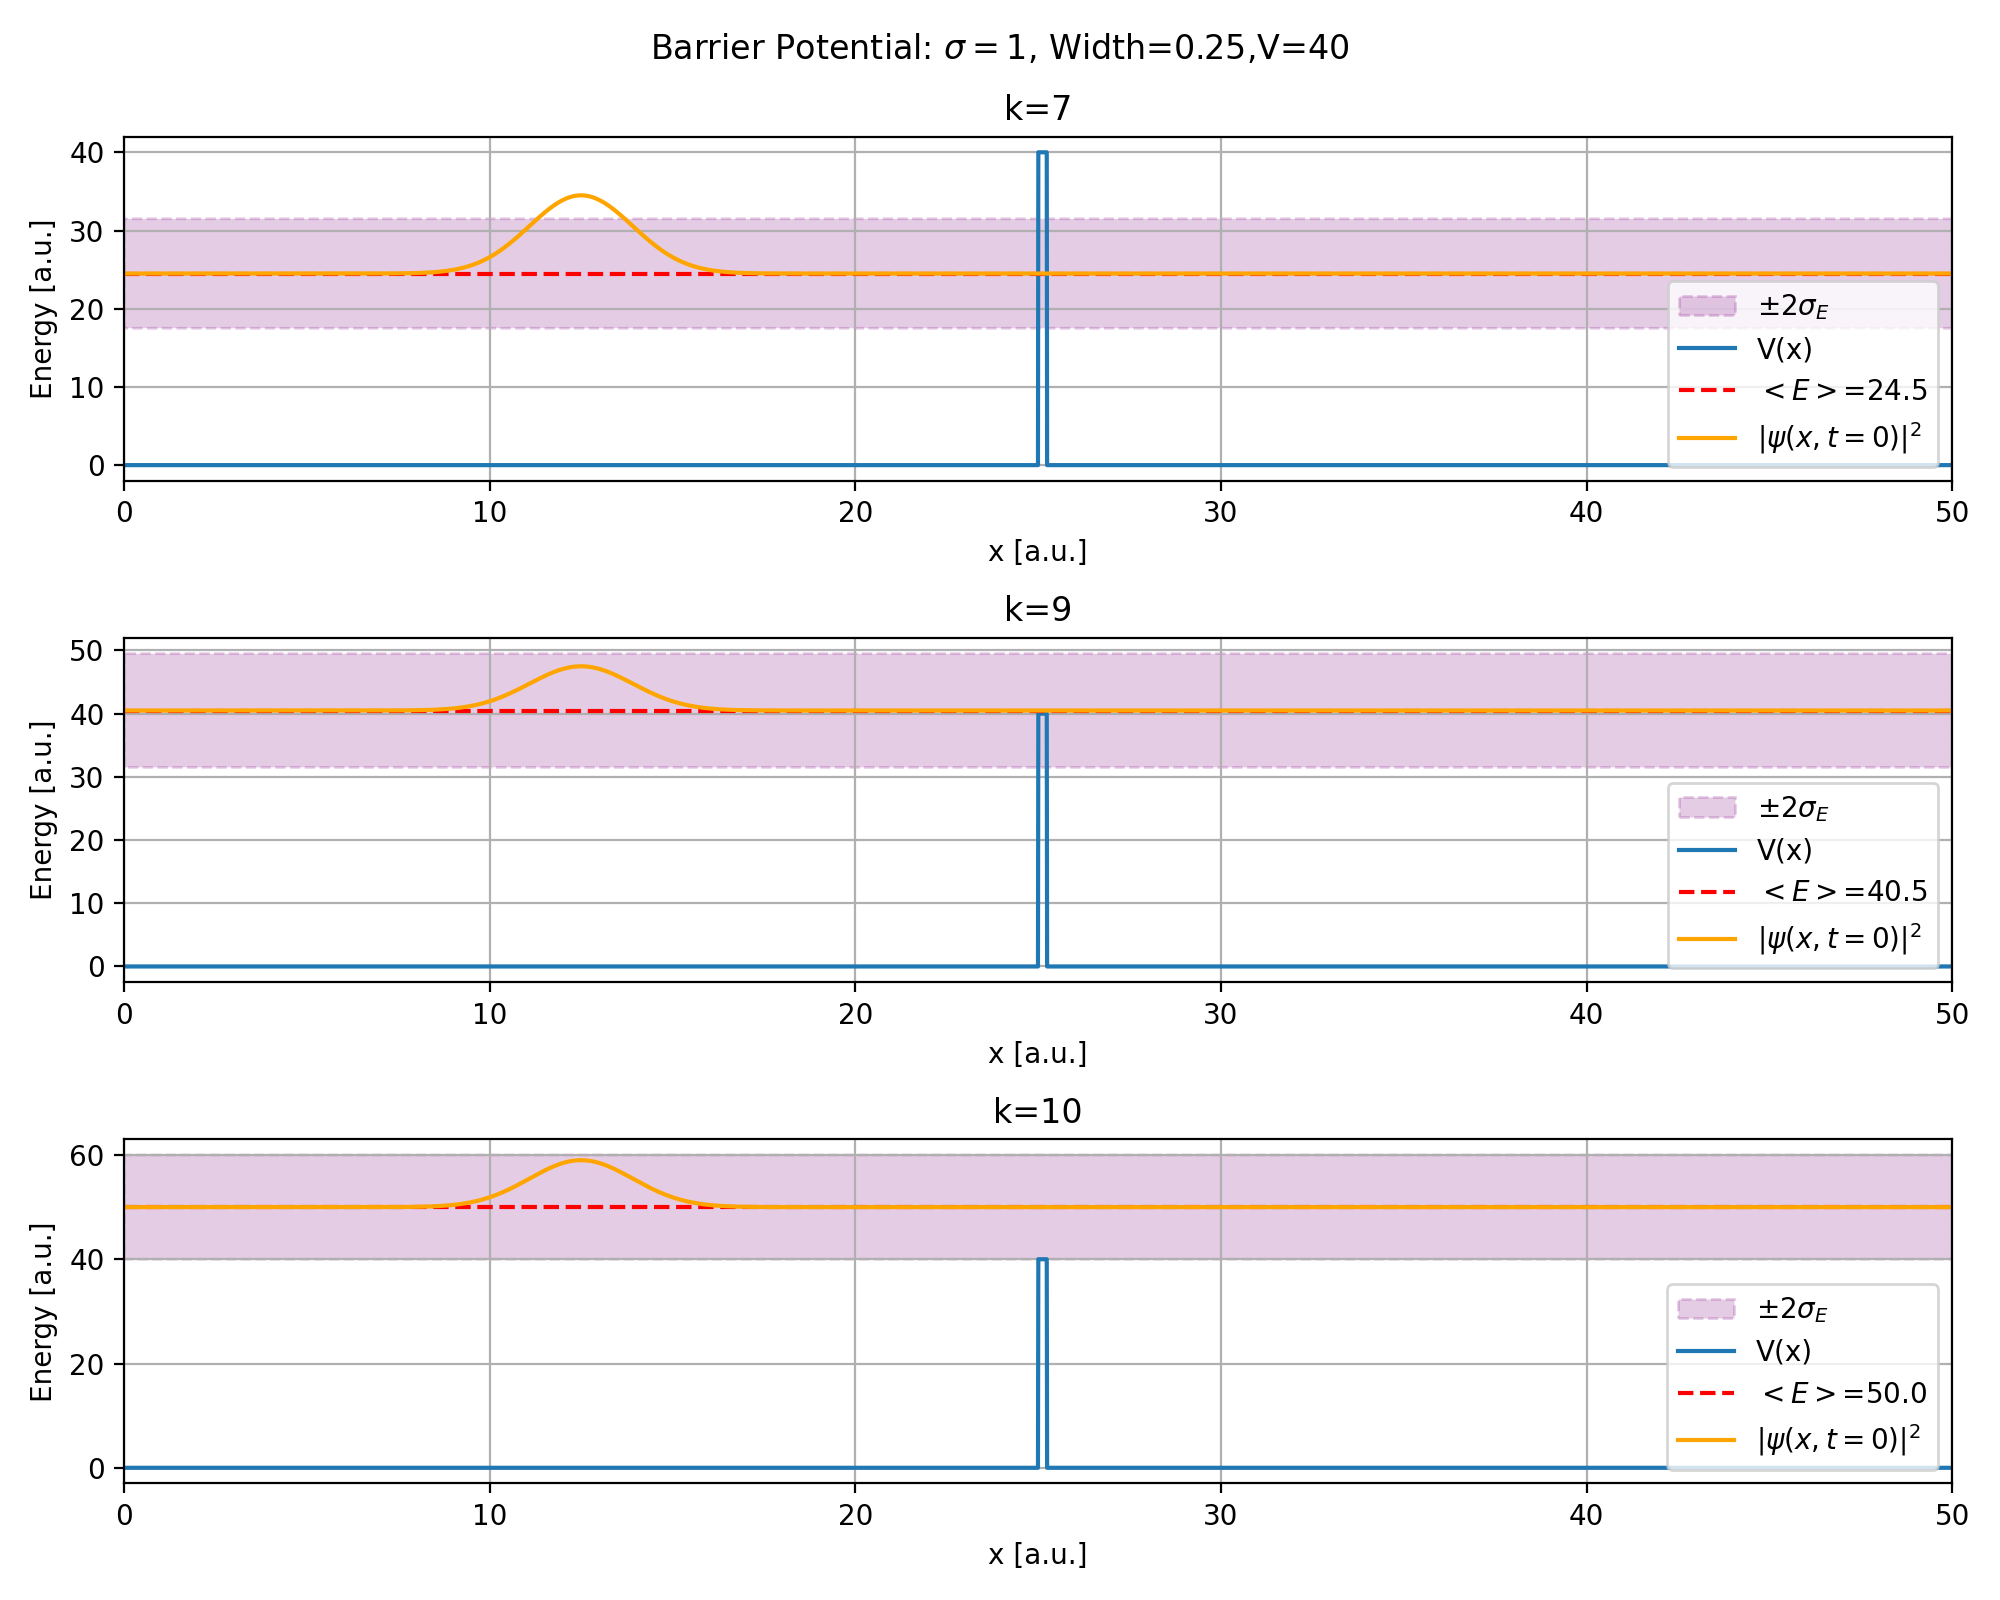

<IPython.core.display.Javascript object>


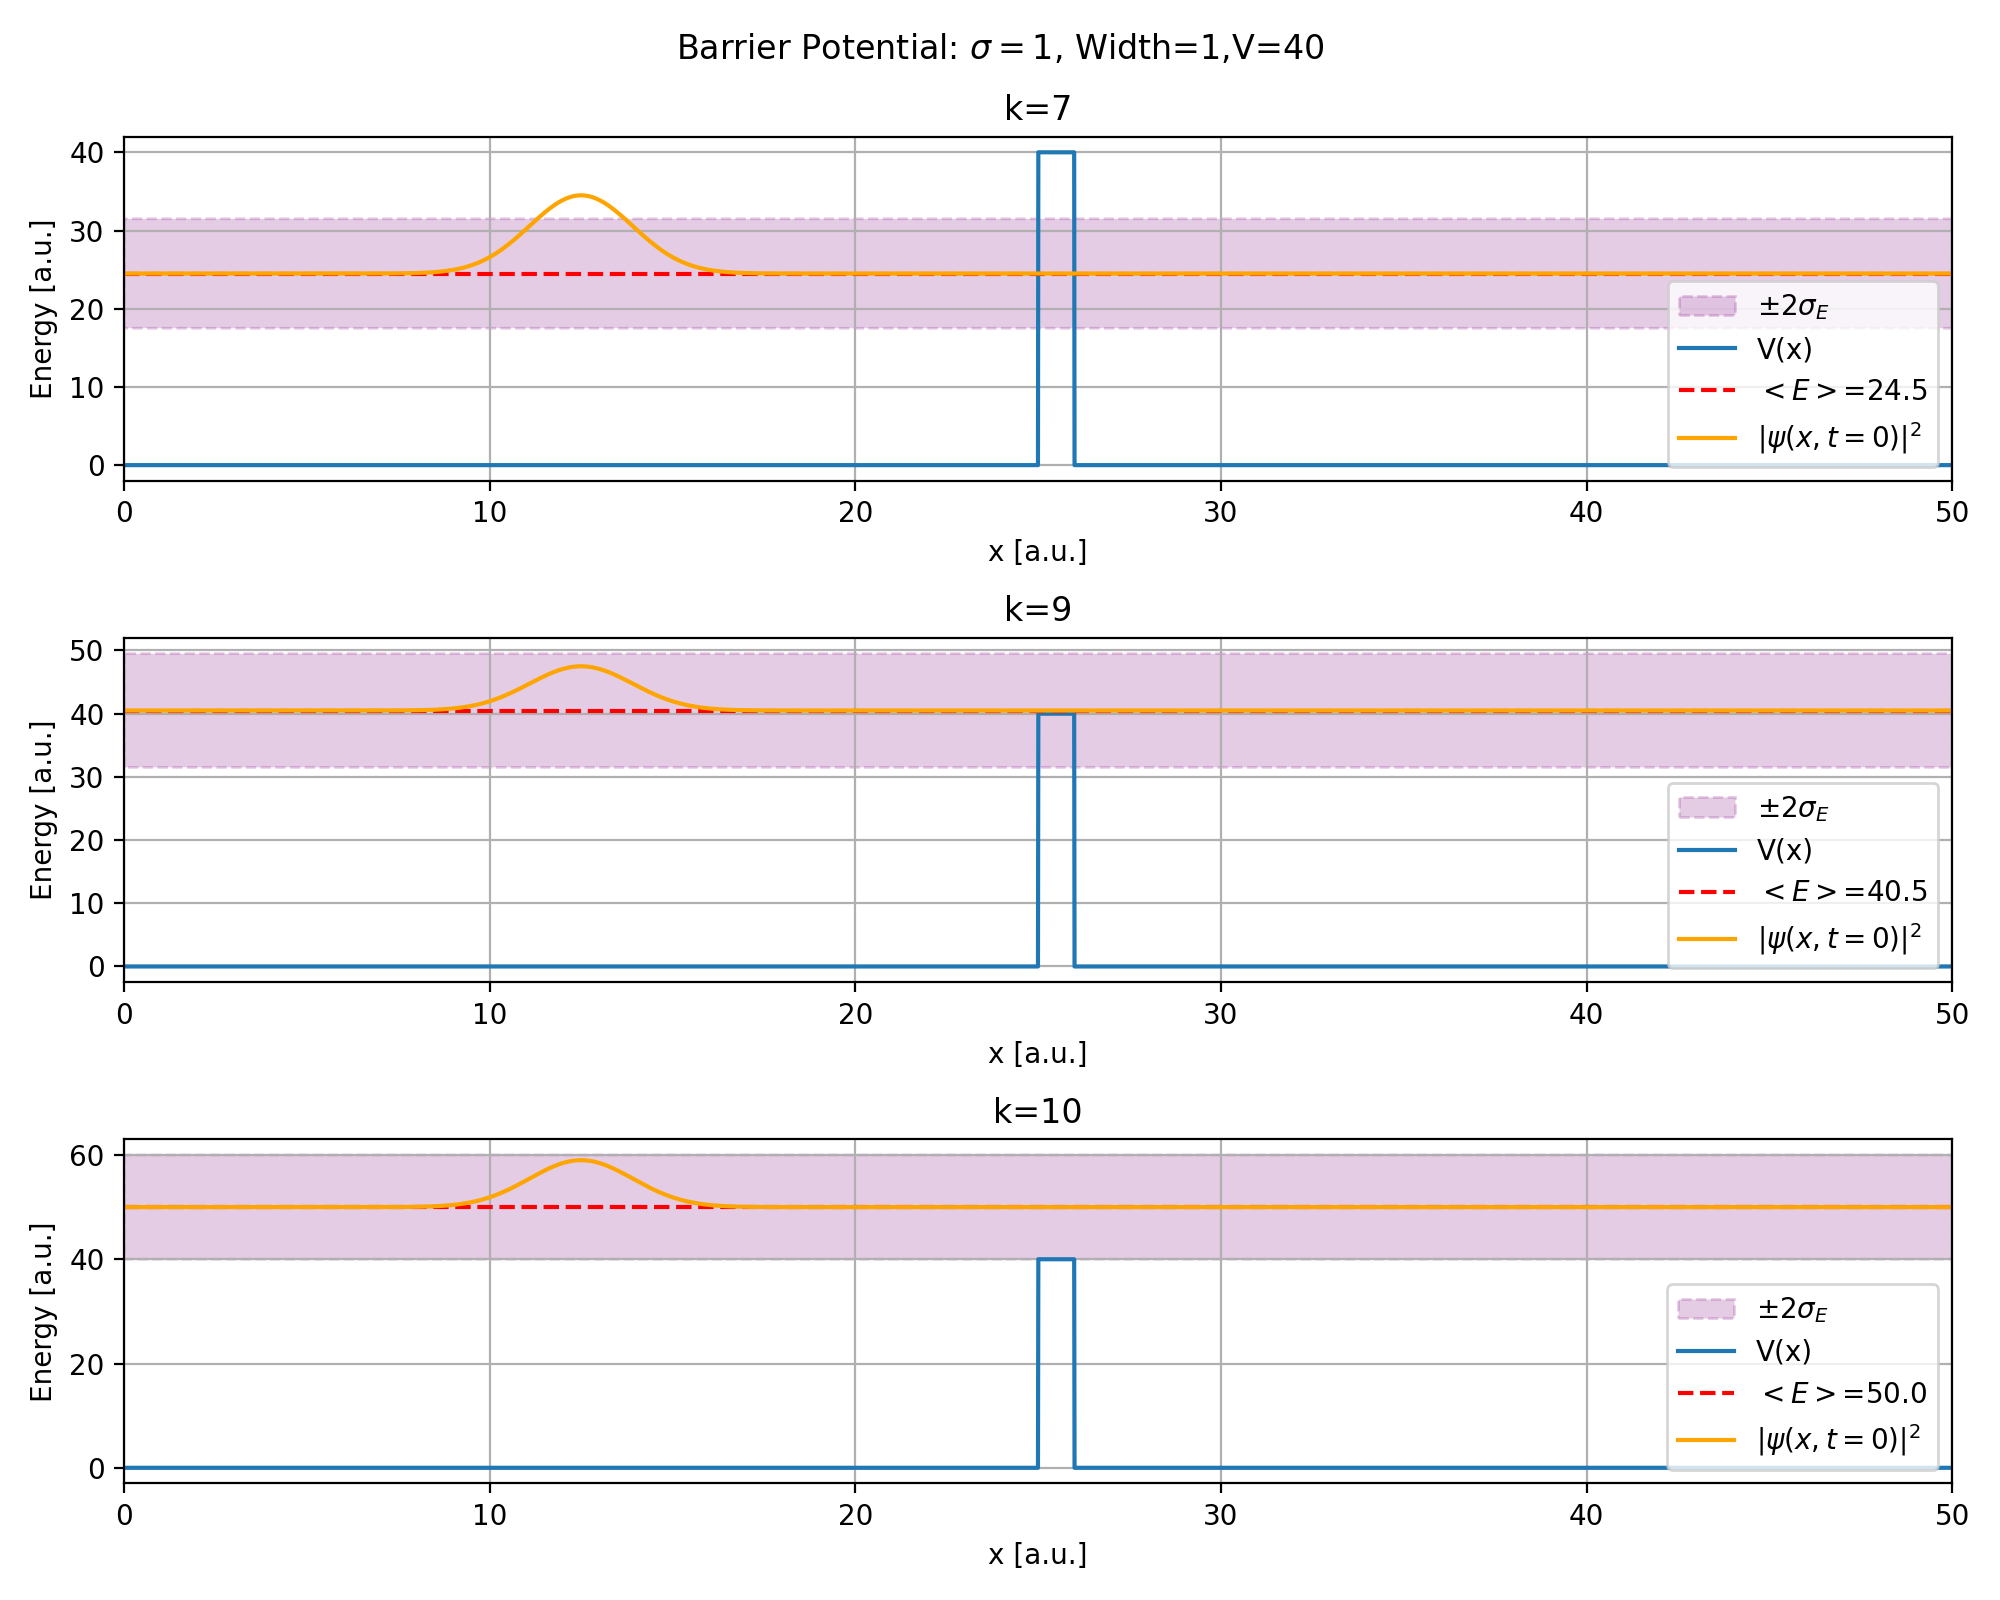

<IPython.core.display.Javascript object>


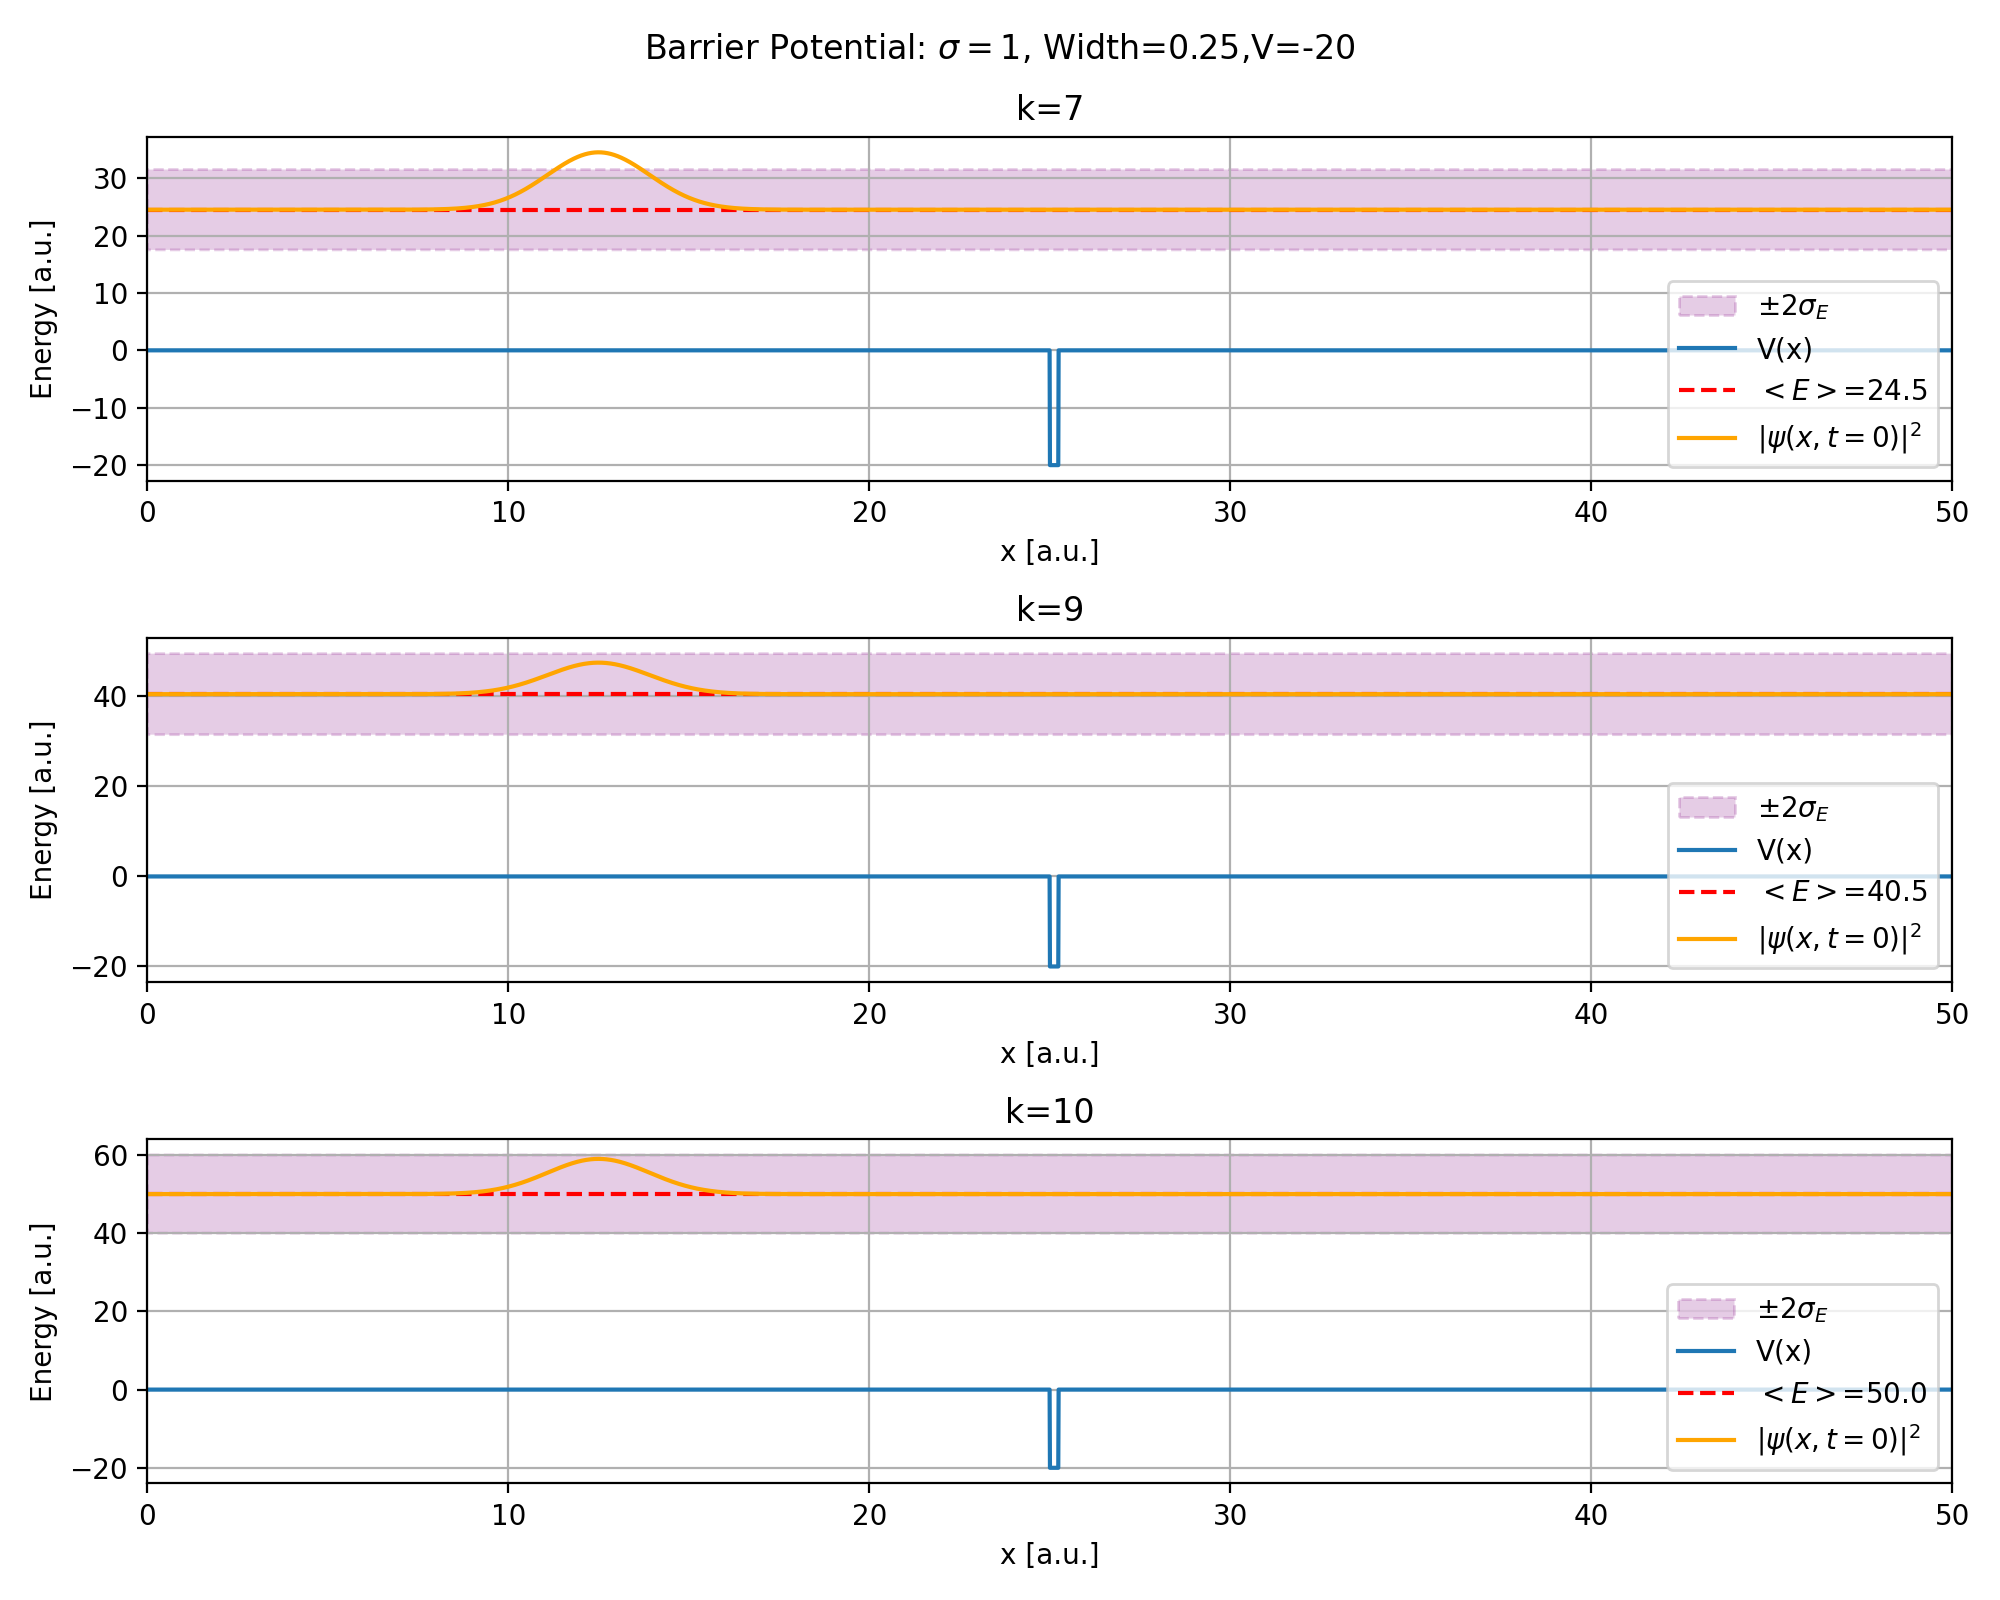

In [3]:
# Your code here...
ks=[7,9,10]

#step potential part
ϕ_step=step(N,40.0)
fig, ax = plt.subplots(3,1,figsize=(10,8))
fig.suptitle('Step Potential: V=40')
for i in range(0,len(ks)):
    energy,e_ul,e_ll,energy_sigma=energy_parameters(ks[i],σₓ)
    psi0=packet(σₓ,x,x0,ks[i])
    psi0_max=(np.abs(psi0)).max()
    scale=(e_ul-energy)/psi0_max
    ax[i].axhline(0.0,xmin=0.0,xmax=.5,linewidth=2.5)
    if ks[i]==9:
        ax[i].axvline(25.0,ymin=0.05,ymax=0.78,linewidth=2.5)
    elif ks[i]==10: 
        ax[i].axvline(25.0,ymin=0.05,ymax=4/6-.025,linewidth=2.5)   
    else:
        ax[i].axvline(25.0,ymin=0.05,ymax=0.95,linewidth=2.5)
    ax[i].axhline(40.0,xmin=.5,xmax=1.0,linewidth=2.5,label='V(x)')
    ax[i].axhline(energy,xmin=0,xmax=1.0,color='red',label=r'$<E>$='+f'{energy}',linestyle='--')
    ax[i].fill_between(x=x, y1=e_ll,y2=e_ul,color='purple',label=r'$\pm2\sigma_E$',linestyle='--',alpha=.2)
    ax[i].plot(x,abs(psi0)*scale+energy,color='orange',label=r'$|\psi(x,t=0)|^2$')
    ax[i].set_title(r'$\sigma=$'+ f'{σₓ}, k={ks[i]}')
    ax[i].legend()
    ax[i].set_xlim((0,50))
    ax[i].set_xlabel('x [m]')
    ax[i].set_ylabel('Energy [a.u.]')
    ax[i].grid('--')
    plt.tight_layout()

    
## barrier potential part 
experiment=[(.25,40),(1,40),(.25,-20)]
for w,v in experiment:
    fig, ax = plt.subplots(3,1,figsize=(10,8))
    fig.suptitle(r'Barrier Potential: $\sigma=$'+ f'{σₓ}, Width={w},V={v}')
    for i in range(0,len(ks)) :
        ϕ_barrier=barrier(N,v,x,dx,w)
        ϕ_barrier=[ϕ_barrier[i][i] for i in range(0,N)]
        psi0=packet(σₓ,x,x0,ks[i])
        psi0_max=(np.abs(psi0)).max()
        scale=(e_ul-energy)/psi0_max
        energy,e_ul,e_ll,energy_sigma=energy_parameters(ks[i],σₓ)  
        ax[i].fill_between(x=x, y1=e_ll,y2=e_ul,color='purple',label=r'$\pm2\sigma_E$',linestyle='--',alpha=.2)
        ax[i].plot(x,ϕ_barrier,label='V(x)')
        ax[i].set_xlim((0,50))

        ax[i].axhline(energy,xmin=0,xmax=1.0,color='red',label=r'$<E>$='+f'{energy}',linestyle='--')
        ax[i].plot(x,abs(psi0)*scale+energy,color='orange',label=r'$|\psi(x,t=0)|^2$')
        ax[i].set_title(f'k={ks[i]}')
        ax[i].legend(loc='lower right')
        ax[i].set_xlabel('x [a.u.]')
        ax[i].set_ylabel('Energy [a.u.]')
        ax[i].grid('--')
        plt.tight_layout()


__________________________________________________________________________________________
Part 3 (9 points)

- write the code to solve the TDSE to get the wave-function vs t given any of the conditions above. 
- make an animation of the wave-function based on the solution
- try it on one or more of the cases above




In [38]:
#  2a
# V=step(N,40.0)
# V=np.array([V[i,i] for i in range(0,N)])

## 2b 
# V=barrier(N,40,x,dx,.25)
# V=np.array([V[i,i] for i in range(0,N)])

## 2c 
# V=barrier(N,40,x,dx,1)
# V=np.array([V[i,i] for i in range(0,N)])


#2d
V=barrier(N,-20,x,dx,.25)
V=np.array([V[i,i] for i in range(0,N)])

k0=10
ψ=packet(σₓ,x,x0,k0)
print("start...")
sol=solve_ivp(ψₜ,t_span=[t0,tf],y0=ψ,t_eval=t,method="RK23", args=(V,))
print("success!")

energy,e_ul,e_ll,energy_sigma=energy_parameters(k0,sigma)

step_=N//2

inte=np.empty(t.size)
inte_l=np.empty(t.size)
inte_r=np.empty(t.size)

for j in range(0,t.size):
    inte[j]=np.sum(np.abs(sol.y[:,j])**2)*dx
    inte_l[j]=np.sum(np.abs(sol.y[:step_:,j])**2)*dx
    inte_r[j]=np.sum(np.abs(sol.y[step_::,j])**2)*dx

start...
success!


<IPython.core.display.Javascript object>


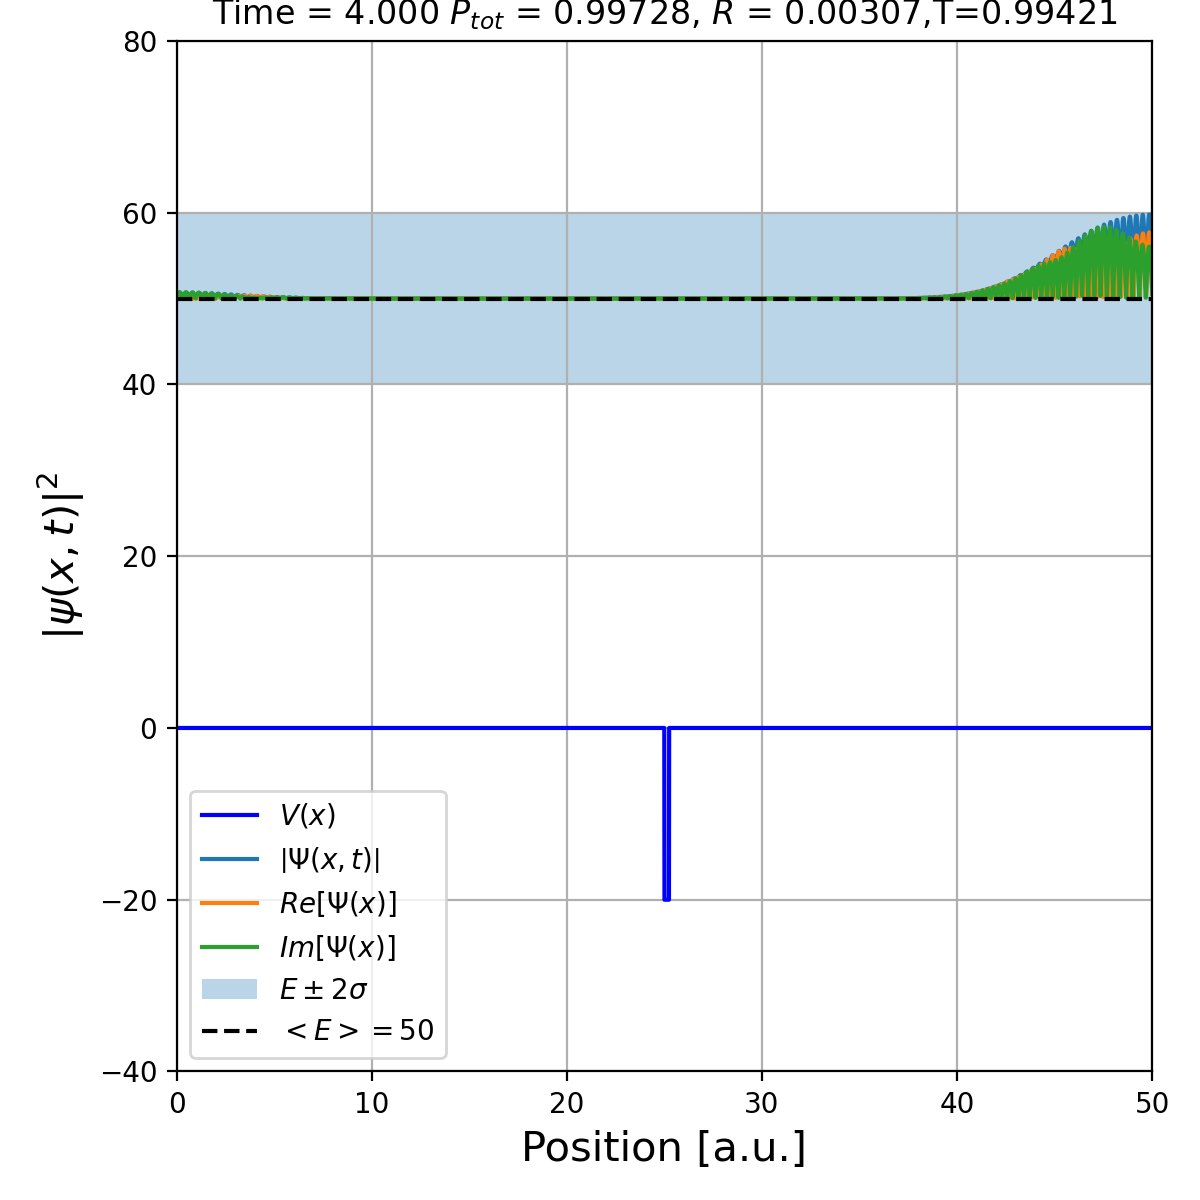

reflection: 0.003071404347104878
transmission: 0.9942075962488868


In [39]:
fig=plt.figure(figsize=(6,6))
fig.clf()
ax1=plt.subplot(1,1,1)
psi0_max=(np.abs(ψ)).max()
scale=(e_ul-energy)/psi0_max
ax1.set_xlim(0,xmax)
ax1.set_ylim(-40,80)
ax1.set_xlabel('Position [a.u.]', fontsize=15)
ax1.set_ylabel(r'$|\psi(x,t)|^2$', fontsize=15)
title=ax1.set_title('')
ax1.plot(x,V,color='blue',label=r'$V(x)$')
line1,=ax1.plot([],[],label=r'$\left| \Psi(x,t)\right|$')
line2,=ax1.plot([],[],label=r'$Re[\Psi(x)]$')
line3,=ax1.plot([],[],label=r'$Im[\Psi(x)]$')
plt.fill_between([x.min(),x.max()],[e_ll,e_ll],[e_ul,e_ul],alpha=.3,label=r'$E\pm 2 \sigma$')
ax1.plot([x.min(),x.max()],[energy,energy],'k--',label='$<E>=${:g}'.format(energy))
ax1.legend()

print("reflection:",inte_l[t.size-1])
print("transmission:",inte_r[t.size-1])

def init():
    line1.set_data([],[])
    line2.set_data([],[])
    line3.set_data([],[])
    return line1,line2,line3,

def animate(i):
    line1.set_data(x,energy+scale*np.abs(sol.y[:,i]))
    line2.set_data(x,energy+scale*np.abs(sol.y[:,i].real))
    line3.set_data(x,energy+scale*np.abs(sol.y[:,i].imag))
    title.set_text(r'Time = {:1.3f} $P_{{tot}}$ = {:1.5f}, $R$ = {:1.5f},T={:1.5f}'.format(sol.t[i],inte[i],inte_l[i],inte_r[i]))
#     title.set_text('Time = {0:1.3f}'.format(sol.t[i]))
    return line1,line2,line3,

anim=animation.FuncAnimation(fig,animate,init_func=init,frames=len(sol.t),interval=5, blit=True,repeat=False)
plt.grid('--')
plt.tight_layout()
plt.show()

Part 4a (1 point)

- for case 2a) above run your script for the 3 $k_0$ and see what is happening
- calcuate the 'transmission' and 'reflection' for each


_______________________________________________________________________
Observations

Clasically, we would assume that any kinetic energy below the potential barrier would completely reflect, as it would not have the energy to pass the barrier. However, in the quantum case, there is a probability that the particle penetrate the barrier. This probability will be in some way positively related to energy and so to k, the wave-vector. 
In this case we set up a potential barrier at 25, and shot a wave packet from 12.5 rightward, varying the k. 

1) For the case of a wave number k=7, we see the wave go right-ward, hit the barrier. At this point, most of the wave reflects and then a negligible part of the wave transmits. In fact, here, the transmission coefficient was around .000002, effectively zero. The reflection coefficient is around .99. 

2) For the case of a wave number k=9, we see the wave go right-ward, hit the barrier. As we would expect, more of the wave is trasmitted now. In fact, we see that the transmission now is a non-negligible .35 , which makes sense since now the kinetic energy hovers slightly above the potential step. The reflection coefficient is around .65. 

3) For the case of a wave number k=10, we see the wave go right-ward, but now it is not hitting the barrier but above it. We should expect that most of the wave transmitts, but should also detect some scattering. In fact, we do see that the reflection coeffecient is around .18, and tranmission .81, so that most is transmitted but a non-negligible portion is reflected. In a classical sitaution we should expect the particle to simply pass the barrier and slow down.


   ------------------
* k=7 R=.99 T=.00002 
* k=9 R=.65 T=.35 
* k=10 R=.18 T=.81
________________________________________________________________________

Part 4b (1 point)

- for case 2b) above run your script for the 3 $k_0$ and see what is happening
- calcuate the 'transmission' and 'reflection' for each

_______________________________________________________________________
Observations

Here we have a barrier potential, where the potential V=40, and the width is .25. Now we have a situation where our wave will be propagating towards and interact with a barrier potential and not a simple step function. Here we should however detect similar features to that above. Clasically, we should expect that when the kinetic energy is less than the potential that there is total reflection, and when the kinetic energy is greater, total transmission. But this will not be the case. Furthermore, in the classical case, the width of the barrier makes no difference. In the quantum case, the length of the width is proportional to the transmission coefficeient. 


1) When the wave number k=7, we see that the wave goes rightward, then hits the barrier, most reflects back and some is transmitted. The fact that there is a finite barrier and not infinite like the step barrier means that more will be constructive intereference and so more transmitted, and we see that the transmission coefficient is .23 and reflection coefficient is .77. 

2) When the wave number k=9, we see that the wave goes rightward, then hits the barrier. The fact that there is a finite barrier and not infinite like the step barrier means that more will be constructive intereference and so more transmitted, and we see that the transmission coefficient is .48 and reflection coefficient is .52. The higher energy value means that more will be more transmitted since the kinetic energy is at the top of the barrier. 

3) When the wave number k=10, we should expect total transmission. Instead, the barrier causes some to be reflected, and in fact a non-negligible reflection coefficient of .38 and transmission coefficient of .62. 


   ------------------
* k=7 R=.77 T=.23
* k=9 R=.52 T=.48 
* k=10 R=.38 T=.62

________________________________________________________________________

Part 4c (1 point)

- for case 2c) above run your script for the 3 $k_0$ and see what is happening
- calcuate the 'transmission' and 'reflection' for each




_______________________________________________________________________
Observations

In this set up we have a barrier potential with height of V=40 and width W=1. We should expect similar dynamics to 2b but the increased width means that the reflection is now two-fold , from the wave hitting the wall at first, and then the wave within the barrier hitting the right wall and reflecting out. There is a similar two-fold character for transmission. 

1) For the case when wave number k=7, the barrier stops almost all of the wave from penetrating and we get an approximately .99 reflection coefficient and a .00001 transmission coefficient. Somehow the width of the potential effected the transmission and reflection, it seemed to have dampened transmission. Maybe here the kinetic energy is not great enough to penetrate both barriers so more is reflected. We get a similar reflection and transmission dynamic to case 2a) which makes sense as case 2a) is the liminal case of a finite width barrier potential. 

2) For the case when wave number k=9, more of the wave than in 1) is transmitted and in fact we get a non-negligible .27 transmission coefficient and .73 reflection coefficient. There is a quite significant jump in transmission now. 

3) For the case when wave number k=10 , we should expect in a classical case a total tranmission but here we will in fact see some reflection , and we will see more than 2b). In fact we see that the transmission coefficient is .68 and reflection .32, which is even higher than in case 2a). 


   ------------------
* k=7 R=.99 T=.00001
* k=9 R=.73 T=.27
* k=10 R=.38 T=.62
________________________________________________________________________

Part 4d (1 point)

- for case 2d) above run your script for the 3 $k_0$ and see what is happening
- calcuate the 'transmission' and 'reflection' for each


________________________________________________
Observations

In this set up, we have a potential finite well, and we will see that despite being above the well, the wave will reflect and trasmit. The greater k is, the greater the kinetic energy the less reflection there will be.  

1) In case of wave number k=7, the reflection coefficient is R=0.05 and transmission T=.95. This is however quite a small reflection and one might expect it to be more. If the barrier instead were a negative step, my prediction is that the reflection would be even greater. 

2) In case of wave number k=9, the wave decreases in reflection we get a negligble transmission coefficient of .01, and approximately .99 reflection coefficient. However, just like we predicted above as k increases so the reflection does too. 

3) For the case of wave number k=10, the wave goes right over the barrier, and some , a tiny amount, is reflected and most transmitted. The reflection coefficient is .003 and the transmission 0.99. Once again, the trend is followed. 

   ------------------
* k=7 R=.05 T=.95
* k=9 R=.01 T=.989
* k=10 R=.003 T=.997
______________________________________________